# (연구) HST example 3

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [논문연구]

### import

In [1]:
## 1. remove trash
#!rm -rf ~/.local/share/Trash/files/*
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
#matplotlib.rc('image', cmap='Greys')
import rpy2 
from adjustText import adjust_text
%load_ext rpy2.ipython
%run heavysnow 

### load data

In [2]:
n=23
f=np.array(pd.read_csv("2021-08-15-MCU-ticket.csv").Worldwide)/1000000
V=np.array(pd.read_csv("2021-08-15-MCU-ticket.csv").Film)
W=np.array(pd.read_csv("2021-08-15-MCU-weights.csv",index_col=0))-np.eye(n,n)

### scatter plot 

In [3]:
df1=pd.DataFrame({'V':V,'f':f,'in_degree':[sum(W[:,i]) for i in range(n)],'out_degree':[sum(W[i,:]) for i in range(n)]})
df1.head()

,V,f,in_degree,out_degree
0,Iron Man,585.174222,2.515815,4.000000
1,The Incredible Hulk,263.427551,0.294608,1.000000
2,Iron Man 2,623.933331,3.107363,4.153846
3,Thor,449.326618,2.241890,2.562500
4,Captain America: The First Avenger,370.569774,0.948269,1.750000


In [4]:
df1['type']='SOLO/NOT-CORE'

In [5]:
df1.loc[map(lambda x: ("Iron Man" in x) or ("Thor" in x) or ("Captain America" in x),df1.V),'type']='SOLO/CORE'
df1.loc[map(lambda x: ("Avengers" in x) or ("Civil War" in x),df1.V),'type']='MULTI'

In [6]:
df1

,V,f,in_degree,out_degree,type
0,Iron Man,585.174222,2.515815,4.000000,SOLO/CORE
1,The Incredible Hulk,263.427551,0.294608,1.000000,SOLO/NOT-CORE
2,Iron Man 2,623.933331,3.107363,4.153846,SOLO/CORE
3,Thor,449.326618,2.241890,2.562500,SOLO/CORE
4,Captain America: The First Avenger,370.569774,0.948269,1.750000,SOLO/CORE
5,The Avengers,1518.812988,4.332114,4.647059,MULTI
6,Iron Man 3,1214.811252,1.690351,3.200000,SOLO/CORE
7,Thor: The Dark World,644.571402,2.147921,2.411765,SOLO/CORE
8,Captain America: The Winter Soldier,714.264267,2.455757,3.266667,SOLO/CORE
9,Guardians of the Galaxy,773.328629,1.212075,1.631579,SOLO/NOT-CORE


In [7]:
fig = ggplot(df1) 
a1= aes(x='in_degree',y='out_degree',size='f',color='type')
a2= aes(x='in_degree',y='out_degree',label='V',color='type')
point1= geom_point(a1)

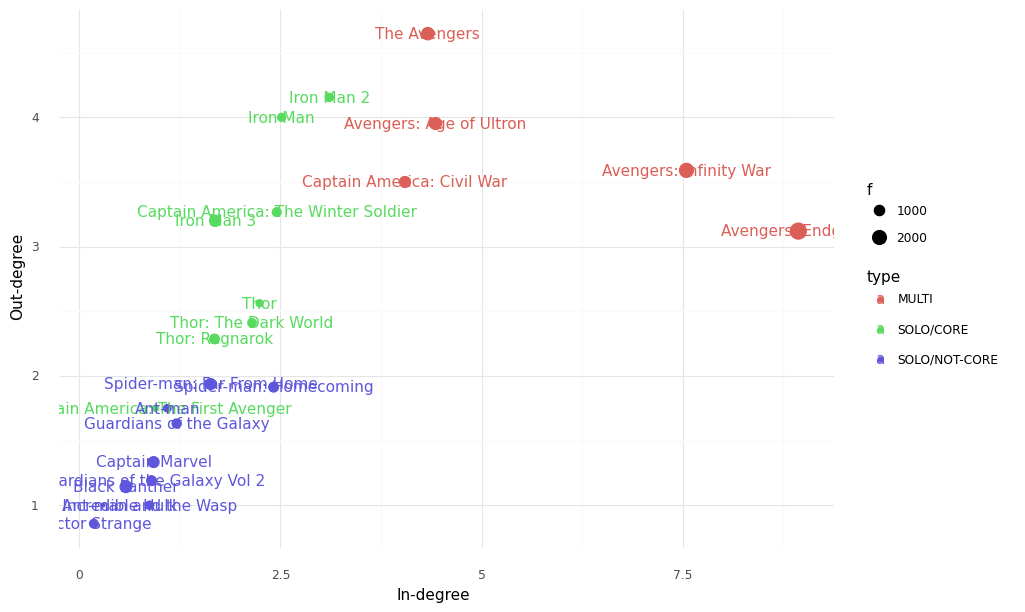

In [8]:
p1=fig+point1\
+xlab("In-degree")+ylab("Out-degree")\
+geom_text(a2)+theme_minimal()
p1=p1.draw()
p1.set_figheight(7)
p1.set_figwidth(10)

In [9]:
adjust_text(p1.axes[0].texts,ax=p1.axes[0], arrowprops=dict(arrowstyle='-', color='gray'))

500

<Figure size 432x288 with 0 Axes>

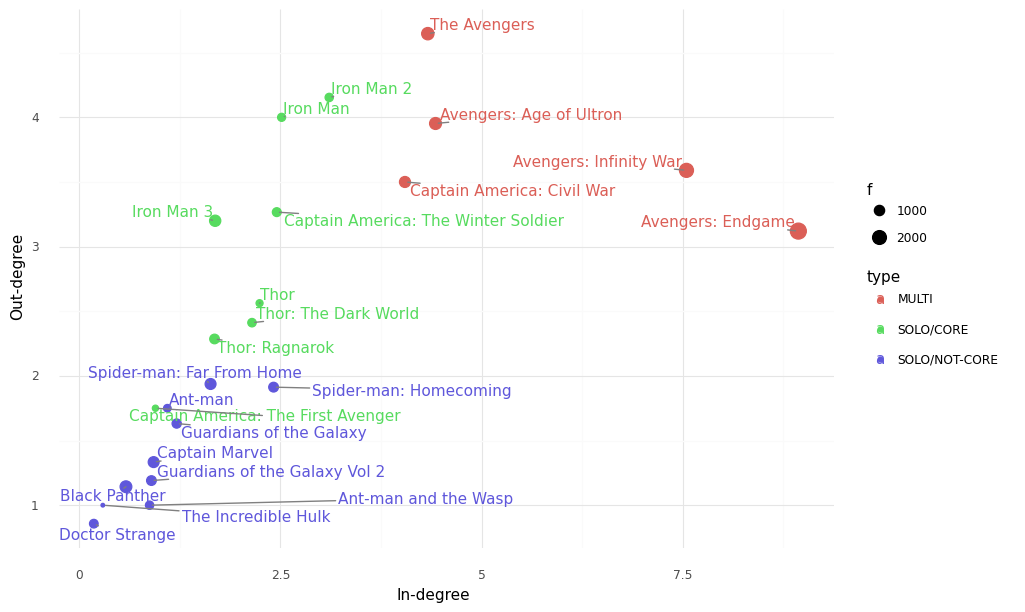

In [10]:
p1

### HST

In [198]:
gs=GraphSignal(V,W,f)
hst=HeavysnowTransform(gs)
hst.snow(tau=120000,b=1)

HST (tau= 120000, b=1)
120000/120000
HST completed and all history is recorded.


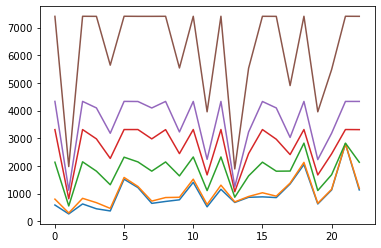

In [199]:
plt.plot(hst.snowygrounds[:,0])
plt.plot(hst.snowygrounds[:,2000])
plt.plot(hst.snowygrounds[:,20000])
plt.plot(hst.snowygrounds[:,40000])
plt.plot(hst.snowygrounds[:,60000])
plt.plot(hst.snowygrounds[:,-1])

### Spectral analysis

In [272]:
gs=GraphSignal(V,hst.eucliddistance,f)
spa=SpectralAnalysis(gs)
spa.graphFouriertransform()
spa.decompose()

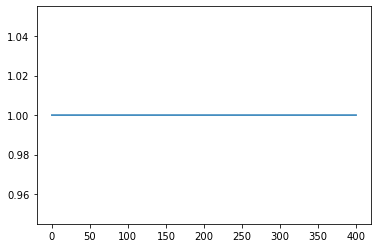

In [279]:
def choose_theta(maxtheta=400):
    y=[]
    x=np.arange(start=0.01,stop=maxtheta,step=0.1)
    for i in range(len(x)):
        hst.adjustingtheta(x[i]) 
        gs=GraphSignal(V,hst.eucliddistance,f)
        spa=SpectralAnalysis(gs)
        spa.graphFouriertransform()
        spa.decompose()        
        y.append(sum(abs(spa.lamb)<0.001))
    plt.plot(x,y)
choose_theta()   

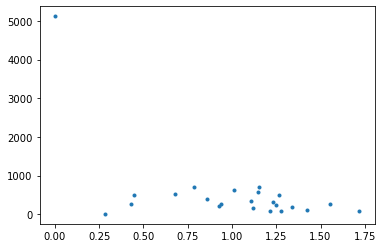

In [342]:
hst.adjustingtheta(210)
gs=GraphSignal(V,hst.graphweight,f)
spa=SpectralAnalysis(gs)
spa.graphFouriertransform()
spa.decompose() 
plt.plot(spa.lamb,abs(spa.fbar),'.')

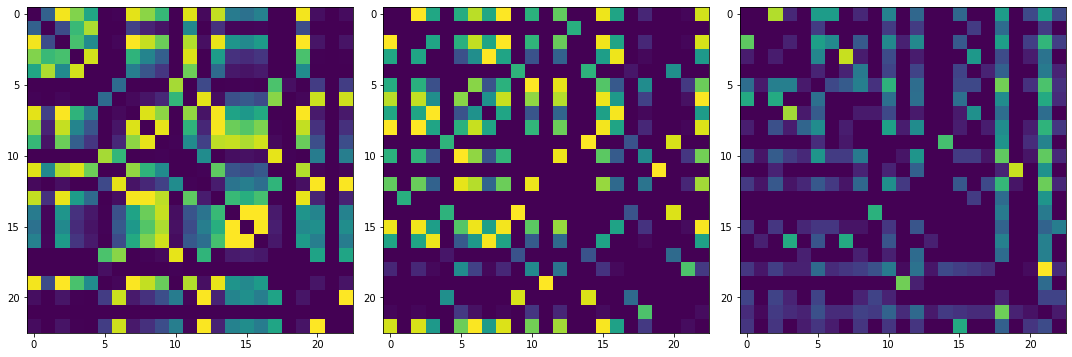

In [343]:
fig, axs= plt.subplots(1,3) 
axs[0].imshow(hst.euclidweight)
axs[1].imshow(hst.snowweight)
axs[2].imshow(hst.graphweight)
fig.set_figwidth(15)
fig.set_figheight(10)
fig.tight_layout()

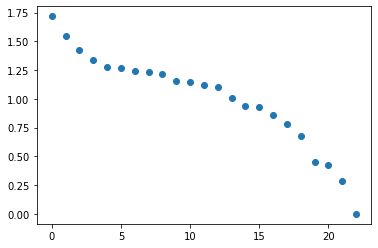

In [381]:
plt.plot(spa.lamb,'o')

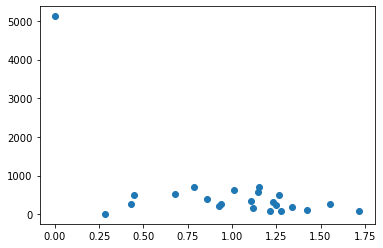

In [382]:
plt.plot(spa.lamb,abs(spa.fbar),'o')

In [383]:
pd.DataFrame(spa.components).stack().reset_index().rename(columns={'level_0':'Vindex','level_1':'comp',0:'fbar'})

,Vindex,comp,fbar
0,0,0,18.941470
1,0,1,42.798488
2,0,2,46.869399
3,0,3,-4.314761
4,0,4,21.580035
...,...,...,...
524,22,18,-206.984457
525,22,19,288.815757
526,22,20,129.021808
527,22,21,226.880298


In [376]:
pd.DataFrame(spa.components).stack().reset_index()

,level_0,level_1,0
0,0,0,18.941470
1,0,1,42.798488
2,0,2,46.869399
3,0,3,-4.314761
4,0,4,21.580035
...,...,...,...
524,22,18,-206.984457
525,22,19,288.815757
526,22,20,129.021808
527,22,21,226.880298


In [389]:
df2.query('comp==22')

,Vindex,comp,fbar,V,fill
22,0,22,-7.783616,Iron Man,SOLO/CORE
45,1,22,40.249428,The Incredible Hulk,SOLO/NOT-CORE
68,2,22,-63.816121,Iron Man 2,SOLO/CORE
91,3,22,-7.197800,Thor,SOLO/CORE
114,4,22,402.024368,Captain America: The First Avenger,SOLO/CORE
137,5,22,-9.715468,The Avengers,MULTI
160,6,22,-339.683491,Iron Man 3,SOLO/CORE
183,7,22,364.918298,Thor: The Dark World,SOLO/CORE
206,8,22,-240.186042,Captain America: The Winter Soldier,SOLO/CORE
229,9,22,88.024382,Guardians of the Galaxy,SOLO/NOT-CORE


In [374]:
df2=pd.DataFrame(spa.components)
df2=df2.stack().reset_index().rename(columns={'level_0':'Vindex','level_1':'comp',0:'fbar'})
df2=df2.merge(pd.DataFrame({'Vindex':range(spa.n),'V':spa.V,'fill':df1.type}))

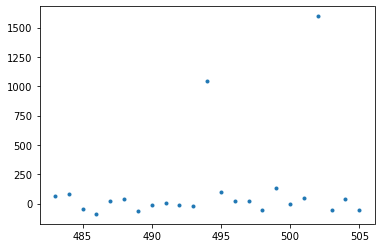

In [375]:
plt.plot(df2.query(" V=='Avengers: Endgame' ")['fbar'],'.')

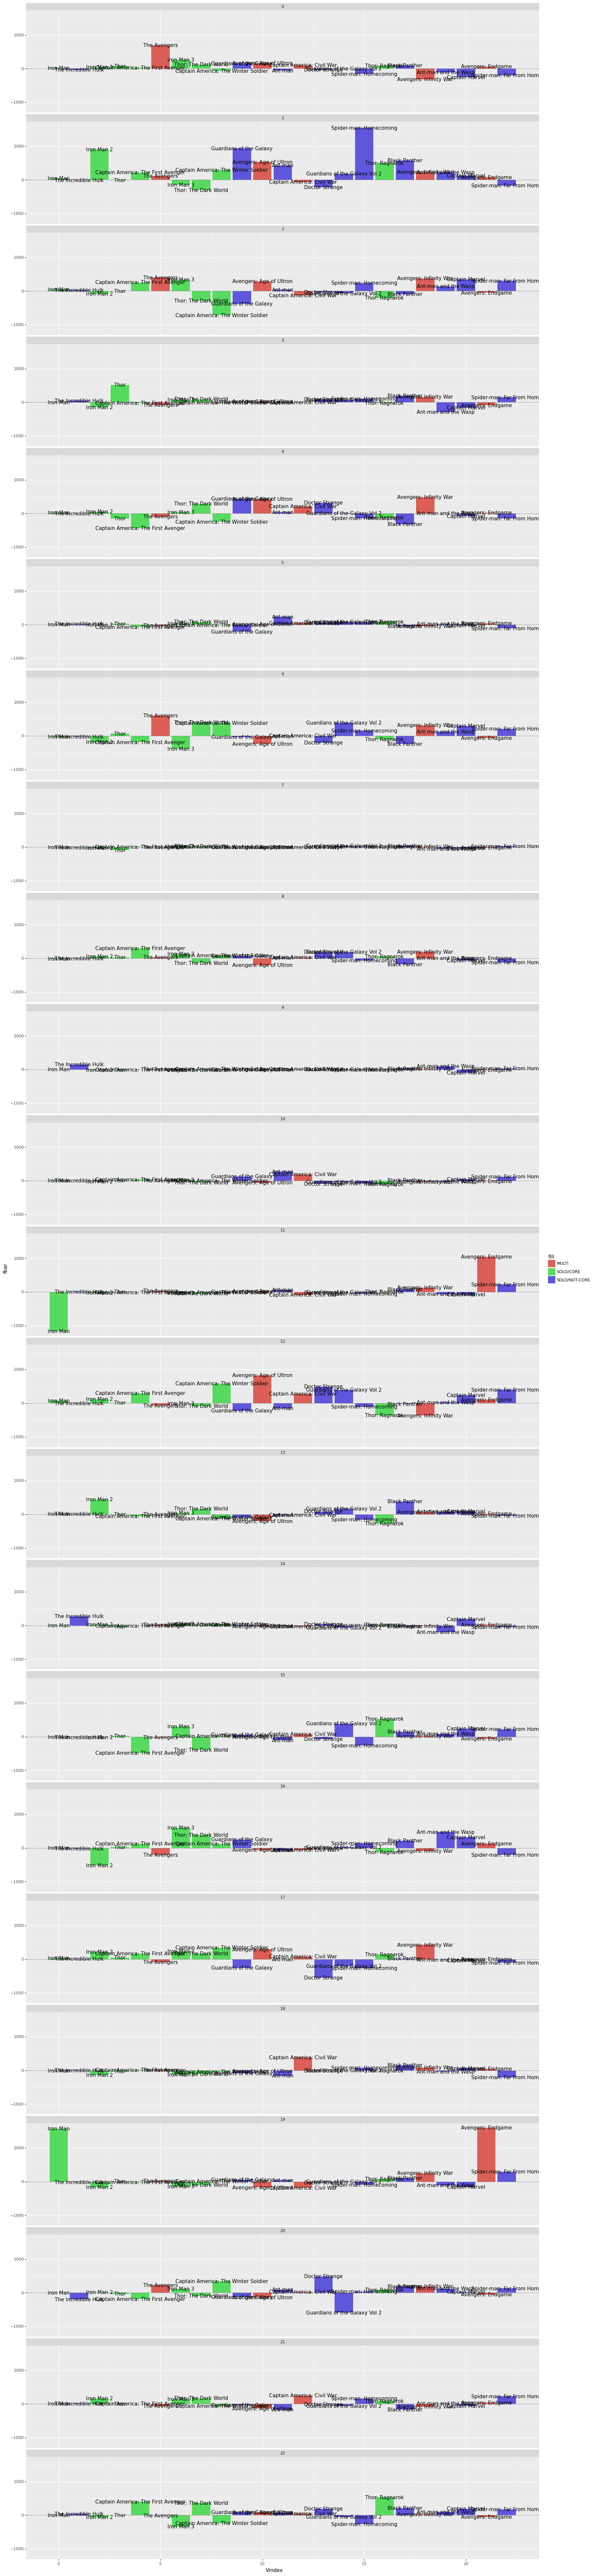

<ggplot: (8735289889287)>

In [359]:
fig=ggplot(df2)
facet=facet_wrap('comp',ncol=1)
a1=aes(x='Vindex',y='fbar',fill='fill')
a2=aes(x='Vindex',y='fbar',label='V')
col=geom_col(a1,alpha=0.5)
hline=geom_hline(yintercept=0,linetype='dashed',color='gray',size=0.3)

p2=fig+facet\
+geom_col(a1)\
+geom_hline(yintercept=0,linetype='dashed',color='gray')\
+theme(figure_size=(20, 100))\
+geom_text(a2)
p2

### 유클리드와 그래프도메인의 정보를 플랏. 

In [ ]:
%%R -r 150 -w 2000 -h 660
source('heavysnow.R')
dat_<-tibble(V)
dat_$f<-as.vector(f)
dat_$divlink<-0
dat_$conlink<-0
dat_$link<-0
dat<-dat_
for(i in 1:23){
    dat$divlink[i]<-sum(W[i,])
    dat$conlink[i]<-sum(W[,i])
    dat$link[i]<-sum(W[i,])+sum(W[i,])
}
p1_<-ggplot(dat)+geom_point(aes(x=f,y=divlink),size=3)+theme_light()+
        geom_text_repel(aes(x=f,y=divlink,label=V),col="gray40")+
        ylab("Out-degree")+xlab("Box office record")+
        geom_hline(aes(yintercept=2),col=2,lty=2,lwd=0.5)+
        geom_vline(aes(xintercept=1000),col=2,lty=2,lwd=0.5)+
        ggtitle("(a)")+theme(plot.title=element_text(face="bold.italic",size=rel(2)))+
        theme(axis.title.x=element_text(face=4,size=rel(1)))+
        theme(axis.title.y=element_text(face=4,size=rel(1)))
p2_<-ggplot(dat)+geom_point(aes(x=f,y=conlink),size=3)+theme_light()+
        geom_text_repel(aes(x=f,y=conlink,label=V),col="gray40")+
        ylab("In-degree")+xlab("Box office record")+
        geom_hline(aes(yintercept=3.75),col=2,lty=2,lwd=0.5)+
        geom_vline(aes(xintercept=1000),col=2,lty=2,lwd=0.5)+
        ggtitle("(b)")+theme(plot.title=element_text(face="bold.italic",size=rel(2)))+
        theme(axis.title.x=element_text(face=4,size=rel(1)))+
        theme(axis.title.y=element_text(face=4,size=rel(1)))
# p3_<-ggplot(dat)+geom_point(aes(x=f,y=link),size=3)+theme_light()+
#         geom_text_repel(aes(x=f,y=link,label=V),col="gray40")+
#         ylab("Graph")+xlab("Box office record")+
#         geom_hline(aes(yintercept=6.25),col=2,lty=2,lwd=0.5)+
#         geom_vline(aes(xintercept=1000),col=2,lty=2,lwd=0.5)+
#         ggtitle("(c)")
p1<-grid.arrange(p1_,p2_,ncol=2)
#ggsave(plot=p1,"./fig/p1.pdf",width=9,height=4.5)

### gfft 수행하고 결과를 저장함. 

In [ ]:
%%R 
g1<-gfft(f,WEuclid)
g2<-gfft(f,Wgraph)
g3<-gfft(f,Whst)

### 아이겐플랏 


In [ ]:
%%R -r 150 -w 1000 -h 400
library(gridExtra)
e1<-eigenplot(g1)+ggtitle("(a) Euclid weights")+theme(plot.title=element_text(face="bold.italic",size=rel(1)))
e2<-eigenplot(g2)+ggtitle("(b) Graph weights")+theme(plot.title=element_text(face="bold.italic",size=rel(1)))
e3<-eigenplot(g3)+ggtitle("(c) HST weights")+theme(plot.title=element_text(face="bold.italic",size=rel(1)))
s1<-specplot(g1)
s2<-specplot(g2)
s3<-specplot(g3)
p2<-grid.arrange(e1,e2,e3,s1,s2,s3,nrow=2)
#ggsave(plot=p2,"./fig/p2.pdf",width=6,height=3)

### 분해 

In [ ]:
%%R -r 300 -w 2500 -h 1500
d1<-decompose(f,WEuclid,V=V) # 0, 35000, 60000, 80000
d2<-decompose(f,Wgraph,V=V) # 0, 35000, 60000, 80000
d3<-decompose(f,Whst,V=V) # 0, 35000, 60000, 80000

d1$case<-"Euclid"
d2$case<-"Graph"
d3$case<-"HST"
decomprslt<-rbind(d1,d2,d3)

In [ ]:
%%R -r 150 -w 2000 -h 4200

decomp_dat<- decomprslt %>% 
                group_by(case,eigenvectorindex) %>% 
                mutate(textsize= 10*(abs(fhat)>50))
        
p3<-ggplot(data=filter(decomp_dat,eigenvectorindex %in% 1:23))+
    geom_col(aes(x=Vindex,y=fhat,fill=fhat>0),width=0.7)+
    geom_text_repel(aes(x=Vindex,y=fhat,label=V,size=textsize),col=1,fontface=4,alpha=0.8,segment.size=0.2,segment.color="gray60",min.segment.length=5,hjust=0.1)+
    scale_radius(range = c(0,1.8))+
    guides(size=FALSE)+
    facet_grid(eigenvectorindex~case)+
    geom_hline(aes(yintercept=0),col="gray60",lty=2)+
    xlab("")+ylab("")+guides(fill=FALSE)+
    theme(axis.text.x=element_text(angle=85,hjust=1,vjust=1,face=4,size=rel(0.7),colour="gray60"))+
    theme_light()+
    theme(strip.text.x = element_text(size = 10, color = "black", face = "bold.italic"))+
    theme(strip.text.y = element_text(size = 10, color = "black", face = "bold.italic"))+
    theme(plot.title=element_text(face="bold.italic",size=rel(1.5)))
show(p3)

# decomp_dat<- decomprslt %>% 
#                 group_by(case,eigenvectorindex) %>% 
#                 mutate(textsize=(fhat>mean(fhat)) *(fhat>240) * ((case=="Euclid")*1.7+
#                                                                  (case!="Euclid")*(eigenvectorindex!=1)*1.7+
#                                                                  (case!="Euclid")*(eigenvectorindex==1)*1))


# p3<-ggplot(data=filter(decomp_dat,eigenvectorindex %in% 1:7))+
#     geom_col(aes(x=Vindex,y=fhat,fill=fhat>0),width=0.7)+
#     geom_text_repel(aes(x=Vindex,y=fhat,label=V,size=textsize),col=1,fontface=4,alpha=0.8,segment.size=0.2,segment.color="gray60",min.segment.length=5,hjust=0.1)+
#     scale_radius(range = c(0,1.8))+
#     guides(size=FALSE)+
#     facet_grid(eigenvectorindex~case)+
#     geom_hline(aes(yintercept=0),col="gray60",lty=2)+
#     xlab("")+ylab("")+guides(fill=FALSE)+
#     theme(axis.text.x=element_text(angle=85,hjust=1,vjust=1,face=4,size=rel(0.7),colour="gray60"))+
#     theme_light()+
#     theme(strip.text.x = element_text(size = 10, color = "black", face = "bold.italic"))+
#     theme(strip.text.y = element_text(size = 10, color = "black", face = "bold.italic"))+
#     theme(plot.title=element_text(face="bold.italic",size=rel(1.5)))
# show(p3)
#ggsave(plot=p3,"./fig/p3.pdf",width=6,height=6)

In [ ]:
%%R
dat3_Euclid <- decomp_dat %>% filter(case=="Euclid",eigenvectorindex==1) %>% select(V,case,eigenvectorindex,textsize,fhat)
dat3_Euclid <- left_join(dat,dat3_Euclid,by="V")

for(j in 2:23){
        decomp_filtered_dat_<- decomp_dat %>% filter(case=="Euclid",eigenvectorindex==j) %>% select(V,case,eigenvectorindex,textsize,fhat)
        decomp_filtered_dat_<- left_join(dat,decomp_filtered_dat_,by="V")
        dat3_Euclid<-rbind(dat3_Euclid,decomp_filtered_dat_)
}

dat3_Graph <- decomp_dat %>% filter(case=="Graph",eigenvectorindex==1) %>% select(V,case,eigenvectorindex,textsize,fhat)
dat3_Graph <- left_join(dat,dat3_Graph,by="V")

for(j in 2:23){
        decomp_filtered_dat_<- decomp_dat %>% filter(case=="Graph",eigenvectorindex==j) %>% select(V,case,eigenvectorindex,textsize,fhat)
        decomp_filtered_dat_<- left_join(dat,decomp_filtered_dat_,by="V")
        dat3_Graph<-rbind(dat3_Graph,decomp_filtered_dat_)
}

dat3_HST <- decomp_dat %>% filter(case=="HST",eigenvectorindex==1) %>% select(V,case,eigenvectorindex,textsize,fhat)
dat3_HST <- left_join(dat,dat3_HST,by="V")

for(j in 2:23){
        decomp_filtered_dat_<- decomp_dat %>% filter(case=="HST",eigenvectorindex==j) %>% select(V,case,eigenvectorindex,textsize,fhat)
        decomp_filtered_dat_<- left_join(dat,decomp_filtered_dat_,by="V")
        dat3_HST<-rbind(dat3_HST,decomp_filtered_dat_)
}
dat3<-rbind(dat3_Euclid,dat3_Graph,dat3_HST)

In [ ]:
%%R -r 300 -w 2000 -h 3000
hull_cyl <- dat3 %>%
            group_by(case,eigenvectorindex) %>% 
            filter(textsize>0) %>% 
            slice(chull(f, divlink))
p4<-ggplot(dat3%>% filter(eigenvectorindex<8))+geom_point(aes(x=f,y=divlink,col=textsize>0,size=fhat*(fhat>0)),alpha=0.8)+
        geom_shape(data=hull_cyl%>% filter(eigenvectorindex<8) ,aes(x=f,y=divlink),alpha=0.05,col="gray30",radius=0.05,expand=0.05)+
        facet_grid(eigenvectorindex~case)+
        scale_size_continuous(range=c(2,2.5))+
        scale_color_manual(values=c("gray80", "gray20"))+
        ylim(0,8)+xlim(0,3000)+
        guides(alpha=F)+
        guides(col=F)+
        guides(size=F)+
        ylab("")+xlab("")+
        geom_hline(aes(yintercept=2),col="gray30",lty=2,lwd=0.2)+
        geom_vline(aes(xintercept=1000),col="gray30",lty=2,lwd=0.2)+
        theme_light()+
        theme(strip.text.x = element_text(size = 10, color = "black", face = "bold.italic"))+
        theme(strip.text.y = element_text(size = 10, color = "black", face = "bold.italic"))+
        theme(plot.title=element_text(face="bold.italic",size=rel(1.5)))
show(p4)
#ggsave(plot=p4,"./fig/p4.pdf",width=7,height=7)

In [ ]:
%%R -r 300 -w 2000 -h 3000
hull_cyl <- dat3 %>%
            group_by(case,eigenvectorindex) %>% 
            filter(textsize>0) %>% 
            slice(chull(f, conlink))
p5<-ggplot(dat3%>% filter(eigenvectorindex<8))+geom_point(aes(x=f,y=conlink,col=textsize>0,size=fhat*(fhat>0)),alpha=0.8)+
        geom_shape(data=hull_cyl%>% filter(eigenvectorindex<8) ,aes(x=f,y=conlink),alpha=0.05,col="gray30",radius=0.05,expand=0.05)+
        facet_grid(eigenvectorindex~case)+
        scale_size_continuous(range=c(2,2.5))+
        scale_color_manual(values=c("gray80", "gray20"))+        
        ylim(0,10)+xlim(0,3000)+
        guides(col=F)+
        guides(alpha=F)+
        guides(size=F)+       
        ylab("")+xlab("")+
        geom_hline(aes(yintercept=3.75),col="gray30",lty=2,lwd=0.2)+
        geom_vline(aes(xintercept=1000),col="gray30",lty=2,lwd=0.2)+
        theme_light()+
        theme(strip.text.x = element_text(size = 10, color = "black", face = "bold.italic"))+
        theme(strip.text.y = element_text(size = 10, color = "black", face = "bold.italic"))+
        theme(plot.title=element_text(face="bold.italic",size=rel(1.5)))
show(p5)
#ggsave(plot=p5,"./fig/p5.pdf",width=7,height=7)        

In [ ]:
%%R -r 300 -w 2000 -h 1500
p_<-grid.arrange(p4,p5,ncol=2)
#ggsave(plot=p6,"./fig/p6.pdf",width=10,height=12)

In [ ]:
%%R -r 200 -w 2000 -h 3000
p6<-grid.arrange(p1,p_,nrow=2,heights=c(3,5))